In [1]:
import pandas as pd
import os

In [2]:
colunas = [
    'NU_ANO_CENSO',
    'CO_ENTIDADE',
    'QT_MAT_BAS', 'QT_MAT_INF', 'QT_MAT_INF_CRE', 'QT_MAT_INF_PRE',
    'QT_MAT_FUND', 'QT_MAT_FUND_AI', 'QT_MAT_FUND_AF',
    'QT_MAT_MED', 'QT_MAT_PROF', 'QT_MAT_PROF_TEC',
    'QT_MAT_EJA',
    'QT_DOC_INF', 'QT_DOC_INF_CRE', 'QT_DOC_INF_PRE',
    'QT_DOC_FUND', 'QT_DOC_FUND_AI', 'QT_DOC_FUND_AF',
    'QT_DOC_MED', 'QT_DOC_PROF', 'QT_DOC_PROF_TEC',
    'QT_DOC_EJA',
    'IN_EJA'
]

In [3]:
caminhos = {
    2022: '../data/microdados_censo_escolar_2022/microdados/dados/microdados_ed_basica_2022.csv',
    2023: '../data/microdados_censo_escolar_2023/dados/microdados_ed_basica_2023.csv',
    2024: '../data/microdados_censo_escolar_2024/dados/microdados_ed_basica_2024.csv'
}

In [4]:
dfs = []
for ano, caminho in caminhos.items():
    print(f'Lendo dados de {ano}...')
    df_ano = pd.read_csv(caminho, encoding='latin-1', sep=';', low_memory=False, usecols=colunas)
    dfs.append(df_ano)
    print(f'{ano}: {df_ano.shape[0]} escolas carregadas')

Lendo dados de 2022...
2022: 224649 escolas carregadas
Lendo dados de 2023...
2023: 217625 escolas carregadas
Lendo dados de 2024...
2024: 215545 escolas carregadas


In [5]:
df = pd.concat(dfs, ignore_index=True)
print(f'DataFrame consolidado: {df.shape[0]} registros x {df.shape[1]} colunas')
df.head()

DataFrame consolidado: 657819 registros x 24 colunas


,NU_ANO_CENSO,CO_ENTIDADE,IN_EJA,QT_MAT_BAS,QT_MAT_INF,QT_MAT_INF_CRE,QT_MAT_INF_PRE,QT_MAT_FUND,QT_MAT_FUND_AI,QT_MAT_FUND_AF,...,QT_DOC_INF,QT_DOC_INF_CRE,QT_DOC_INF_PRE,QT_DOC_FUND,QT_DOC_FUND_AI,QT_DOC_FUND_AF,QT_DOC_MED,QT_DOC_PROF,QT_DOC_PROF_TEC,QT_DOC_EJA
0,2022,11022558,0.0,6.0,0.0,0.0,0.0,6.0,6.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2022,11024275,1.0,200.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
2,2022,11024291,0.0,9.0,0.0,0.0,0.0,9.0,9.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,2022,11024372,0.0,118.0,17.0,0.0,17.0,101.0,43.0,58.0,...,1.0,0.0,1.0,7.0,1.0,6.0,0.0,0.0,0.0,0.0
4,2022,11024666,0.0,161.0,18.0,0.0,18.0,143.0,66.0,77.0,...,1.0,0.0,1.0,19.0,3.0,16.0,0.0,0.0,0.0,0.0


In [6]:
# Filtrar escolas com EJA
df_eja = df[df['IN_EJA'] == 1].copy()
print(f'Total de escolas com EJA: {len(df_eja)}')
df_eja.head()

Total de escolas com EJA: 89405


,NU_ANO_CENSO,CO_ENTIDADE,IN_EJA,QT_MAT_BAS,QT_MAT_INF,QT_MAT_INF_CRE,QT_MAT_INF_PRE,QT_MAT_FUND,QT_MAT_FUND_AI,QT_MAT_FUND_AF,...,QT_DOC_INF,QT_DOC_INF_CRE,QT_DOC_INF_PRE,QT_DOC_FUND,QT_DOC_FUND_AI,QT_DOC_FUND_AF,QT_DOC_MED,QT_DOC_PROF,QT_DOC_PROF_TEC,QT_DOC_EJA
1,2022,11024275,1.0,200.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
37,2022,11006757,1.0,666.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0
39,2022,11006773,1.0,1434.0,0.0,0.0,0.0,1193.0,0.0,1193.0,...,0.0,0.0,0.0,41.0,0.0,41.0,0.0,0.0,0.0,13.0
50,2022,11007281,1.0,620.0,0.0,0.0,0.0,466.0,0.0,466.0,...,0.0,0.0,0.0,21.0,0.0,21.0,0.0,0.0,0.0,15.0
53,2022,11007451,1.0,950.0,0.0,0.0,0.0,818.0,678.0,140.0,...,0.0,0.0,0.0,28.0,27.0,9.0,0.0,0.0,0.0,12.0


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

plt.style.use('seaborn-v0_8')

In [8]:
# Preparar dados para clusterização
colunas_cluster = [col for col in df_eja.columns if col not in ['NU_ANO_CENSO', 'CO_ENTIDADE', 'IN_EJA']]
df_cluster = df_eja[colunas_cluster].copy()

# Tratar valores nulos - preencher com 0
df_cluster = df_cluster.fillna(0)

print(f'Dados para clusterização: {df_cluster.shape[0]} registros x {df_cluster.shape[1]} colunas')
print(f'Colunas usadas: {colunas_cluster}')

Dados para clusterização: 89405 registros x 21 colunas
Colunas usadas: ['QT_MAT_BAS', 'QT_MAT_INF', 'QT_MAT_INF_CRE', 'QT_MAT_INF_PRE', 'QT_MAT_FUND', 'QT_MAT_FUND_AI', 'QT_MAT_FUND_AF', 'QT_MAT_MED', 'QT_MAT_PROF', 'QT_MAT_PROF_TEC', 'QT_MAT_EJA', 'QT_DOC_INF', 'QT_DOC_INF_CRE', 'QT_DOC_INF_PRE', 'QT_DOC_FUND', 'QT_DOC_FUND_AI', 'QT_DOC_FUND_AF', 'QT_DOC_MED', 'QT_DOC_PROF', 'QT_DOC_PROF_TEC', 'QT_DOC_EJA']


In [9]:
# Escalar os dados
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

print(f'Dados escalados: {df_scaled.shape}')
print(f'Média por feature (após escala): {df_scaled.mean(axis=0)[:5]}')
print(f'Desvio padrão por feature (após escala): {df_scaled.std(axis=0)[:5]}')

Dados escalados: (89405, 21)
Média por feature (após escala): [ 5.08637493e-18 -9.53695300e-18  1.27159373e-17 -1.58949217e-17
 -7.62956240e-17]
Desvio padrão por feature (após escala): [1. 1. 1. 1. 1.]


2


3
4
5
6
7
8
9
10


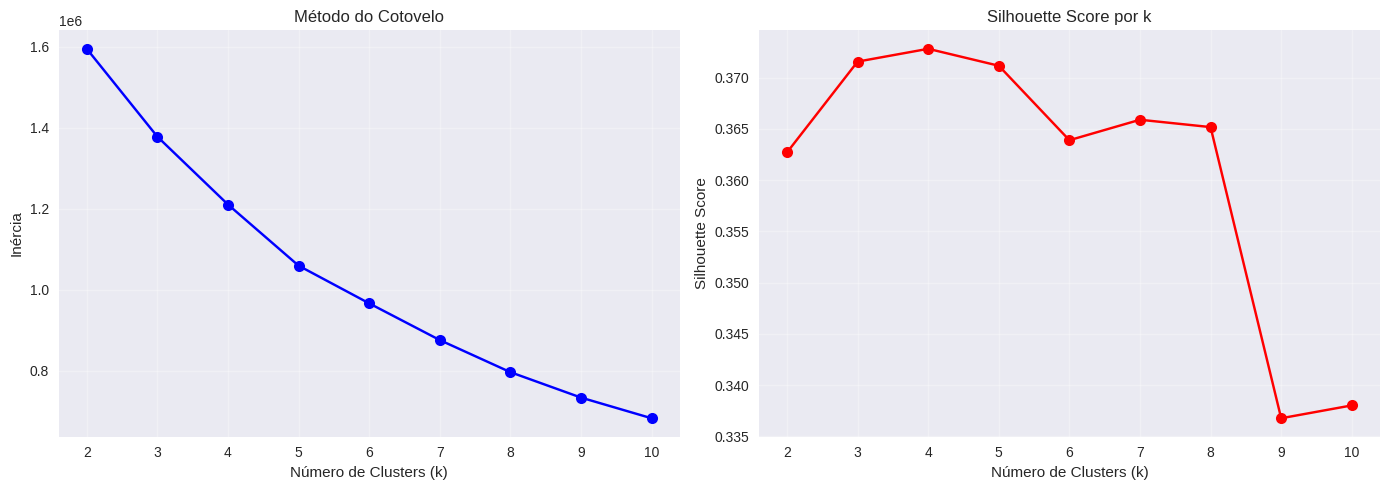

Valores de Inércia: {2: 1594672.148469663, 3: 1377876.8972656415, 4: 1210470.9373172154, 5: 1059605.9621165118, 6: 966611.5330918608, 7: 876034.9294507101, 8: 796831.6319377322, 9: 734113.044505308, 10: 683053.7133795591}
Valores de Silhouette: {2: 0.362705483181759, 3: 0.3715620743992309, 4: 0.3728109172672865, 5: 0.3711578080050731, 6: 0.36389630361096675, 7: 0.36589241701780895, 8: 0.36517522450914025, 9: 0.3367793962320122, 10: 0.3380316386245466}


In [18]:
# Método do cotovelo para encontrar número ideal de clusters
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    print(k)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Plotar método do cotovelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-', markersize=8)
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia')
ax1.set_title('Método do Cotovelo')
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por k')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Exibir valores
print('Valores de Inércia:', dict(zip(k_range, inertias)))
print('Valores de Silhouette:', dict(zip(k_range, silhouette_scores)))

In [13]:
# Treinar KMeans com k ótimo (baseado no método do cotovelo e silhouette)
k_optimo = 2  # Ajuste este valor após analisar os gráficos anteriores
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
kmeans.fit(df_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print(f'KMeans treinado com k={k_optimo}')
print(f'Inércia: {kmeans.inertia_:.2f}')
print(f'Distribuição dos clusters: {np.bincount(labels)}')

KMeans treinado com k=2
Inércia: 1594672.15
Distribuição dos clusters: [66080 23325]


In [14]:
# Calcular métricas de avaliação do cluster
silhouette_avg = silhouette_score(df_scaled, labels)
calinski_harabasz = calinski_harabasz_score(df_scaled, labels)
davies_bouldin = davies_bouldin_score(df_scaled, labels)

print('Métricas de Avaliação do Cluster:')
print(f'  Silhouette Score: {silhouette_avg:.4f} (varia de -1 a 1, quanto maior melhor)')
print(f'  Calinski-Harabasz Index: {calinski_harabasz:.2f} (quanto maior melhor)')
print(f'  Davies-Bouldin Index: {davies_bouldin:.4f} (quanto menor melhor)')
print(f'  Inércia: {kmeans.inertia_:.2f}')

Métricas de Avaliação do Cluster:
  Silhouette Score: 0.3627 (varia de -1 a 1, quanto maior melhor)
  Calinski-Harabasz Index: 15856.65 (quanto maior melhor)
  Davies-Bouldin Index: 1.6912 (quanto menor melhor)
  Inércia: 1594672.15


In [16]:
# Adicionar coluna de cluster ao df_eja
df_eja['cluster'] = labels

print(f'Coluna cluster adicionada ao df_eja')
print(f'Distribuição de escolas por cluster:')
print(df_eja['cluster'].value_counts().sort_index())

Coluna cluster adicionada ao df_eja
Distribuição de escolas por cluster:
cluster
0    66080
1    23325
Name: count, dtype: int64


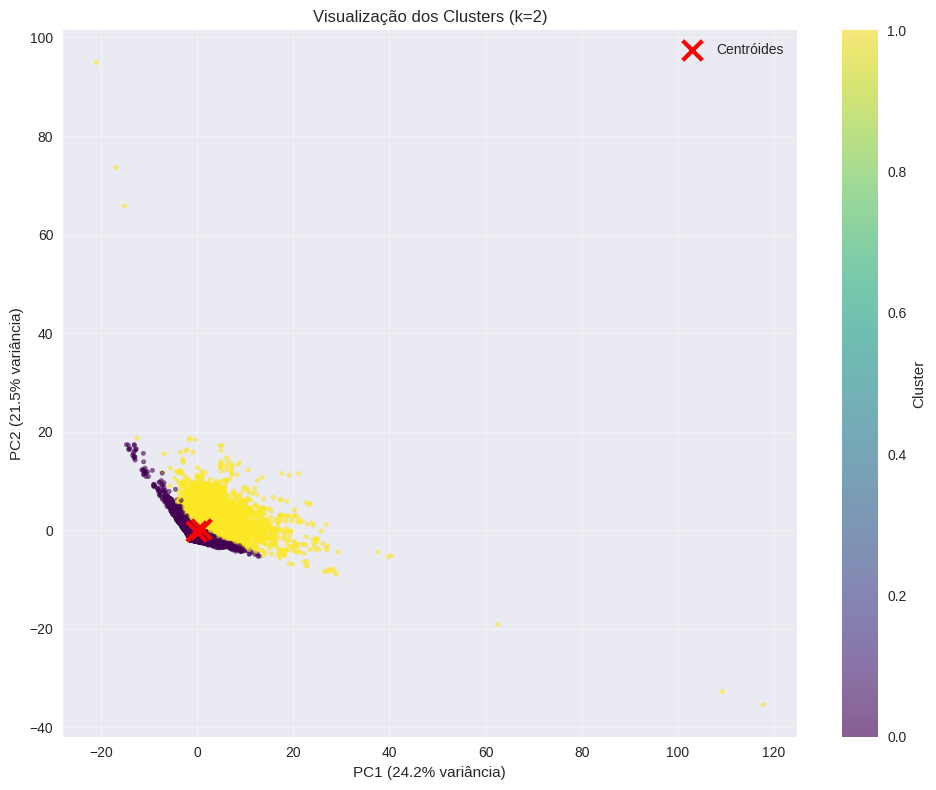

Variância explicada pelos 2 primeiros componentes: 45.73%


In [17]:
# Visualizar clusters usando PCA para redução de dimensionalidade
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Plotar clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels, cmap='viridis', alpha=0.6, s=10)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, linewidths=3, label='Centróides')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
plt.title(f'Visualização dos Clusters (k={k_optimo})')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Variância explicada pelos 2 primeiros componentes: {pca.explained_variance_ratio_.sum()*100:.2f}%')